In [223]:
import os
import json
import argparse
import configparser
import time
from tqdm import tqdm
import sys

import numpy as np
import pandas as pd
import torchvision.transforms as transform
import torchvision
import torch
import torch.nn as nn

# Plot dist of poison and unpoisoned 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# Add paernt dir
import sys
sys.path.append('..')

try: 
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.xla_multiprocessing as xmp
except: pass

from utils.utils import *
from utils.utils_clf import *
from utils.utils_baselines import *
from utils.EBM_models import create_ebm
from utils.Diff_models import create_diff
from diffusers import UNet2DModel, DDPMScheduler, ScoreSdeVeScheduler

os.environ['XRT_TPU_CONFIG'] = 'localservice;0;localhost:51011'
device = xm.xla_device() 

In [225]:
EPS=16

In [197]:
parser = argparse.ArgumentParser(description='PyTorch Poison Attack')
args = parser.parse_args([])
args.data_dir = '/home/sunaybhat/data'
args.ebm_path = '/home/sunaybhat/data/PureGen_Models/EBMSNGAN32/cifar10_nf[128].pt'
args.diff_path = '/home/sunaybhat/data/PureGen_Models/DM_UNET/cinic10_imagenet_DDPM[250]_nf[L].pt'
args.poison_type = 'Narcissus'
args.poison_mode = 'from_scratch'
args.dataset = 'cifar10'
args.add_rand_noise = False
args.baseline_defense = 'None'
args.aug_rand_transforms = False
args.aug_cutout = False
args.ebm_filter = None
args.data_key = 'Baseline'
args.noise_sz_narcissus = 32
args.noise_eps_narcissus = 16
args.num_images_narcissus = 5000
args.batch_size = 1024
args.model = 'ResNet18'

target_index=4

In [4]:
def get_sample_energies(data,ebm_model,device,targets=True):
    forward_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    energy_list = []

    with torch.no_grad():
        for batch in tqdm(data):

            if targets:
                input, target = batch
            else:
                input = batch

            input = forward_norm(input).unsqueeze(0).to(device)       
            energy = ebm_model(input.to(device)).item()
            energy_list[0] = energy)

            xm.mark_step()

    return energy_list


def ebm_purify(ebm_model,X_input,langevin_steps=150,langevin_temp=1e-4):
    """
    Purifies the input tensor X using the Energy-Based Model (EBM).

    Parameters:
    X_input (torch.Tensor): The input tensor to be purified.
    langevin_steps (int, optional): The number of Langevin steps for the EBM. Defaults to 20.
    langevin_temp (float, optional): The temperature for the Langevin dynamics. Defaults to 1e-4.
    requires_grad (bool, optional): If True, the input tensor X is cloned and requires gradient. Defaults to True.
    device_type (str, optional): The type of device to use ('xla' or other). Defaults to 'xla'.

    Returns:
    torch.Tensor: The purified tensor.
    """

    # EBM Update
    langevin_init_noise = 0.0
    langevin_eps = 1.25e-2

    # Set true for MCMC
    X_purify = torch.autograd.Variable(X_input.clone(), requires_grad=True)

    X_purify = X_purify + langevin_init_noise * torch.randn_like(X_purify)

    for ell in range(langevin_steps):
        energy = ebm_model(X_purify).sum() / langevin_temp
        grad = torch.autograd.grad(energy, [X_purify], create_graph=False)[0]
        X_purify.data -= ((langevin_eps ** 2) / 2) * grad
        X_purify.data += langevin_eps* torch.randn_like(grad)
        xm.mark_step()
    xm.mark_step()

    return X_purify.detach()


def diff_purify(diff_model,scheduler, X_input,diff_steps,device):
    """
    Purifies the input tensor X using the HF-DDPM model.

    Parameters:
    X_input (torch.Tensor): The original input tensor.

    Returns:
    torch.Tensor: The purified tensor.
    """

    with torch.no_grad():

        reverse_images = scheduler.add_noise(X_input,torch.randn(X_input.shape),timesteps = torch.LongTensor([diff_steps])).to(device)

        for i, t in enumerate(scheduler.timesteps[-diff_steps:]):
            residual = diff_model(reverse_images, timestep=t,return_dict=False)[0]
            reverse_images = scheduler.step(residual, t, reverse_images).prev_sample

            xm.mark_step()
        xm.mark_step()

    return reverse_images


def purify(data, ebm_model, diff_model, scheduler, device, mcmc_steps=0, diff_T=0, batch_size=64):
    forward_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    inverse_norm = transforms.Compose([transforms.Normalize((-1, -1, -1), (2, 2, 2)), transforms.ToPILImage()])

    # Initialize tensor to store purified data
    purified_data = torch.zeros((len(data), 3, 32, 32)).to(device)

    # Process data in batches
    for i in tqdm(range(0, len(data), batch_size)):
        batch_data = data[i:i+batch_size]
        batch_data = torch.stack([forward_norm(img[0]) for img in batch_data]).to(device)

        if mcmc_steps > 0:
            batch_data = ebm_purify(ebm_model, batch_data, langevin_steps=mcmc_steps).squeeze(0)

        if diff_T > 0:
            batch_data = diff_purify(diff_model, scheduler, batch_data, diff_T, device)

        purified_data[i:i+batch_size] = batch_data

        xm.mark_step()

    return [inverse_norm(img.squeeze(0)) for img in list(torch.unbind(purified_data, dim=0))]


In [202]:
ebm_model = create_ebm('EBMSNGAN32',128)
ebm_model.load_state_dict(torch.load(os.path.join(args.data_dir,args.ebm_path)))
ebm_model.to(device);

diff_model = create_diff('DM_UNET', [128, 128, 256, 256, 512, 512], 2, num_res_blocks=2)
diff_model.load_state_dict(torch.load(os.path.join(args.data_dir,args.diff_path)))
diff_model.to(device);

scheduler = DDPMScheduler(num_train_timesteps=1000)

## Poisoned and Purified Energies

100%|██████████| 5000/5000 [00:27<00:00, 183.99it/s]


Number of clean samples: 5000, Mean/STD of clean energies: -0.09812614819207229/0.12516322764878468


100%|██████████| 5000/5000 [00:27<00:00, 184.66it/s]


Number of poisoned samples: 5000, Mean/STD of poisoned energies: 0.3099544107973576/0.027502285091754435


100%|██████████| 5000/5000 [00:28<00:00, 172.93it/s]


...

100%|██████████| 5000/5000 [00:29<00:00, 169.24it/s]


Number of purified samples: 5000, Mean/STD of purified energies: 0.08211172515358776/0.0955448593761594


100%|██████████| 5000/5000 [00:28<00:00, 174.22it/s]


Number of random samples: 5000, Mean/STD of random energies: 1.793818314909935/0.022613622062773484


Text(0.5, 1.0, 'Energy Distribution of Clean, Poisoned, and Purified Samples')

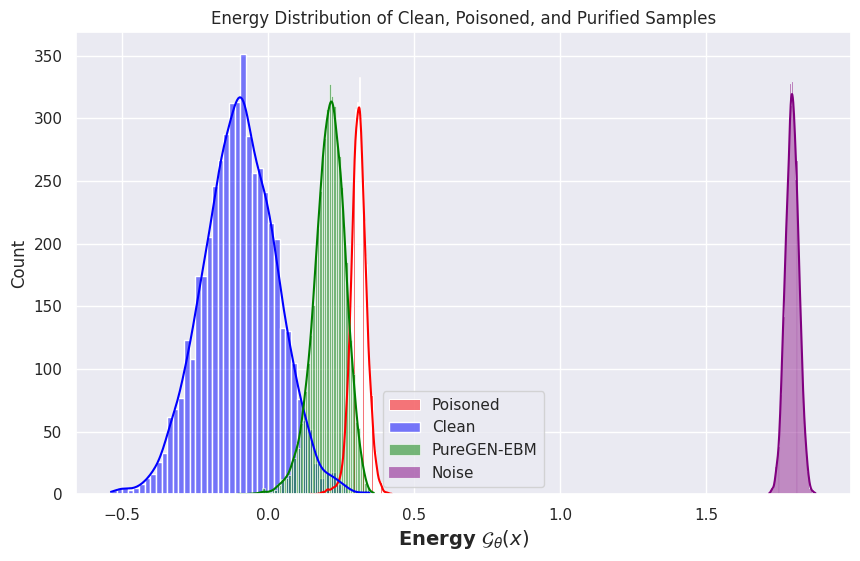

In [226]:
### Clean Data
clean_data = torch.load('/home/sunaybhat/data/PureGen_PoisonDefense/cifar10/Baseline.pt')
# Sample 5000 images of this list
idxs = np.random.choice(len(clean_data),5000,replace=False)
clean_data = [clean_data[i] for i in idxs]
clean_energies = get_sample_energies(clean_data,ebm_model,device)

print(f'Number of clean samples: {len(clean_energies)}, Mean/STD of clean energies: {np.mean(clean_energies)}/{np.std(clean_energies)}')

### Poisoned Data
poisoned_data = torch.load(f'/home/sunaybhat/data/PureGen_PoisonDefense/cifar10/Poisons/from_scratch/Narcissus/size=32_eps={EPS}_num=5000/Baseline/5.pth')[0]
poisoned_energies = get_sample_energies(poisoned_data,ebm_model,device)

print(f'Number of poisoned samples: {len(poisoned_energies)}, Mean/STD of poisoned energies: {np.mean(poisoned_energies)}/{np.std(poisoned_energies)}')

### EBM Purification
pure_ebm_data = purify(poisoned_data,ebm_model,diff_model,scheduler,device,mcmc_steps=750,diff_T=0)

pure_ebm_energies = get_sample_energies(pure_ebm_data,ebm_model,device,targets=False)

print(f'Number of purified samples: {len(pure_ebm_energies)}, Mean/STD of purified energies: {np.mean(pure_ebm_energies)}/{np.std(pure_ebm_energies)}')

### Diffusion Purification
pure_diff_data = purify(poisoned_data,ebm_model,diff_model,scheduler,device,mcmc_steps=0,diff_T=75)

pure_diff_energies = get_sample_energies(pure_diff_data,ebm_model,device,targets=False)

print(f'Number of purified samples: {len(pure_diff_energies)}, Mean/STD of purified energies: {np.mean(pure_diff_energies)}/{np.std(pure_diff_energies)}')

### Random Baseline
rand_data = [transforms.ToPILImage()(torch.rand(3,32,32)) for _ in range(NUM)]
rand_energies = get_sample_energies(rand_data,ebm_model,device,targets=False)

print(f'Number of random samples: {len(rand_energies)}, Mean/STD of random energies: {np.mean(rand_energies)}/{np.std(rand_energies)}')

plt.figure(figsize=(10, 6))


sns.histplot(poisoned_energies, color='red', label='Poisoned', kde=True)
sns.histplot(clean_energies, color='blue', label='Clean', kde=True)
sns.histplot(pure_ebm_energies, color='green', label='PureGEN-EBM', kde=True)
sns.histplot(rand_energies, color='purple', label='Noise', kde=True)

plt.xlabel(r'Energy $\mathcal{G}_{\theta}(x)$', fontsize=14, fontweight='bold')
plt.legend()
plt.title('Energy Distribution of Clean, Poisoned, and Purified Samples')

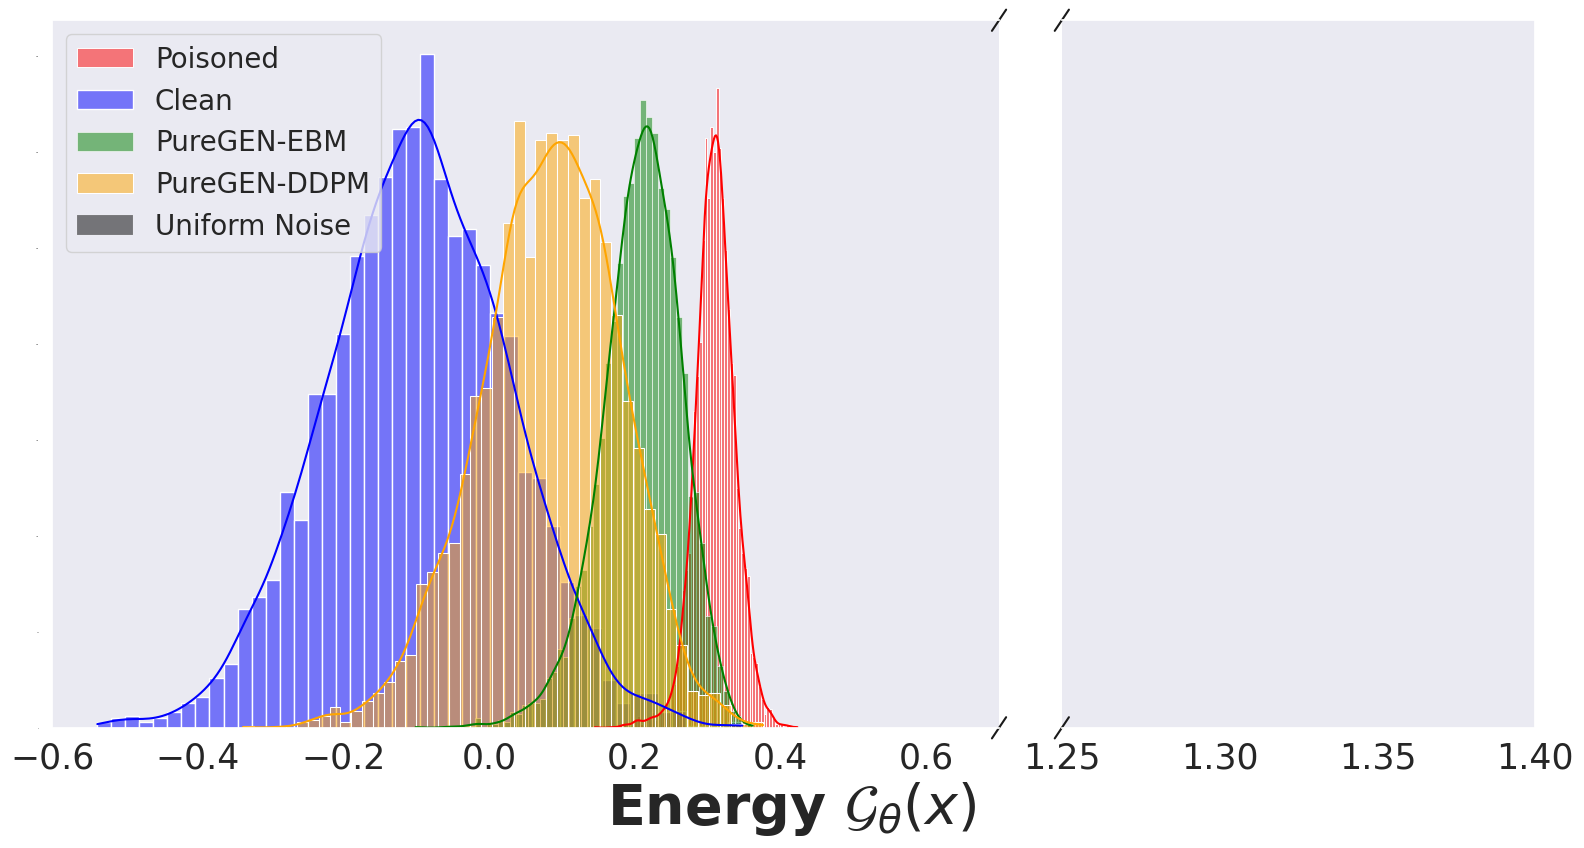

In [227]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(16, 8),width_ratios=[2, 1])

# Ax1
sns.histplot(poisoned_energies, color='red', label='Poisoned', kde=True, ax=ax1)
sns.histplot(clean_energies, color='blue', label='Clean', kde=True, ax=ax1)
sns.histplot(pure_ebm_energies, color='green', label='PureGEN-EBM', kde=True, ax=ax1)
sns.histplot(pure_diff_energies, color='orange', label='PureGEN-DDPM', kde=True, ax=ax1)
sns.histplot(rand_energies, color='black', label='Uniform Noise', kde=True, ax=ax1)

# Ax2
# sns.histplot(poisoned_energies, color='red', label='Poisoned', kde=True, ax=ax2)
# sns.histplot(clean_energies, color='blue', label='Clean', kde=True, ax=ax2)
# sns.histplot(pure_ebm_energies, color='green', label='PureGEN-EBM', kde=True, ax=ax2)
sns.histplot(rand_energies, color='black', label='Noise', kde=True, ax=ax2)

ax1.legend()
ax2.legend()


ax1.set_xlim(-0.6, 0.7)  # outliers only
ax2.set_xlim(1.25, 1.4)  # most of the data

plt.subplots_adjust(wspace=0.05)

plt.setp(ax1.get_legend().get_texts(), fontsize='26')
# move ax1 legeend to top left
ax1.legend(loc='upper left', fontsize='20')

ax2.legend().remove()

d = .015  # how big to make the diagonal lines in axes coordinates

# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
# bottom-right diagonal
ax1.plot((1 - d/2, 1 + d/2), (-d, +d), **kwargs) 
# top-right diagonal
ax1.plot((1 - d/2, 1 + d/2), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # switch to the right axes
# top-left diagonal
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
# bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)  

fig.text(0.5, -0.02, r'Energy $\mathcal{G}_{\theta}(x)$', ha='center', va='center',fontsize=40, fontweight='bold')

# Make x ticks bigger
ax1.tick_params(axis='x', which='major', labelsize=25)
ax2.tick_params(axis='x', which='major', labelsize=25)
# Remove y ticks
ax1.tick_params(axis='y', which='major', labelsize=0)
ax2.tick_params(axis='y', which='major', labelsize=0)

ax1.grid(False)
ax2.grid(False)

# Remove lines in between plots
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)


ax1.set_ylabel('')

plt.tight_layout()
plt.savefig(f'energy_dist_Narc{EPS}.pdf',bbox_inches='tight')

## Purification plots

Image index: 31488


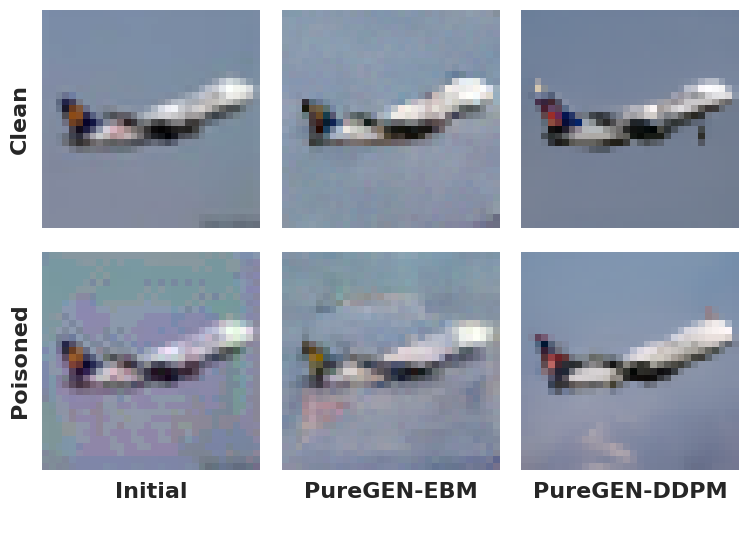

In [96]:
forward_transform = transforms.Compose([transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Sample a random or selecte dimage
sample_img = torch.load('/home/sunaybhat/data/PureGen_PoisonDefense/cifar10/Baseline.pt')
idx = np.random.randint(0,50000)
idx = 31488
sample_img = transforms.ToTensor()(sample_img[idx][0])
print(f'Image index: {idx}')

# Apply Poison
noise_npy = torch.from_numpy(np.load('/home/sunaybhat/data/Poisons/Narcissus/cifar10/size=32_eps=8/best_noise_lab4.npy'))
poisoned_img = sample_img + noise_npy * 0.5

# Purify EBM
pure_ebm_poisoned = ebm_purify(ebm_model,forward_transform(poisoned_img).to(device),langevin_steps=500).squeeze(0)
pure_ebm_clean = ebm_purify(ebm_model,forward_transform(sample_img.unsqueeze(0)).to(device),langevin_steps=500).squeeze(0)

# Purify Diff
pure_diff_poisoned = diff_purify(diff_model,scheduler,forward_transform(poisoned_img).to(device),75,device)
pure_diff_clean = diff_purify(diff_model,scheduler,forward_transform(sample_img.unsqueeze(0)).to(device),75,device)

fig, ax = plt.subplots(2,3, figsize=(9, 6))
# Norm image
sample_img = (sample_img - sample_img.min()) / (sample_img.max() - sample_img.min())
ax[0,0].imshow(sample_img.permute(1,2,0))
ax[0,0].axis('off')
ax[0,0].text(-0.1, 0.5, 'Clean', va='center', ha='center', rotation='vertical', fontsize=16, fontweight='bold',transform=ax[0,0].transAxes)

ax[1,0].imshow(poisoned_img.squeeze().permute(1,2,0))
poisoned_image = (poisoned_img - poisoned_img.min()) / (poisoned_img.max() - poisoned_img.min())
ax[1,0].axis('off')
ax[1,0].text(-0.1, 0.5, 'Poisoned', va='center', ha='center', rotation='vertical', fontsize=16, fontweight='bold',transform=ax[1,0].transAxes)
ax[1,0].text(0.5, -0.1, 'Initial', ha='center', va='center', transform=ax[1,0].transAxes, fontsize=16, fontweight='bold')

pure_ebm_clean = (pure_ebm_clean - pure_ebm_clean.min()) / (pure_ebm_clean.max() - pure_ebm_clean.min())
ax[0,1].imshow(pure_ebm_clean.permute(1,2,0).cpu().detach())
ax[0,1].axis('off')

pure_ebm_poisoned = (pure_ebm_poisoned - pure_ebm_poisoned.min()) / (pure_ebm_poisoned.max() - pure_ebm_poisoned.min())
ax[1,1].imshow(pure_ebm_poisoned.permute(1,2,0).cpu().detach())
ax[1,1].axis('off')
ax[1,1].text(0.5, -0.1, 'PureGEN-EBM', ha='center', va='center', transform=ax[1,1].transAxes, fontsize=16, fontweight='bold')
             
pure_diff_clean = (pure_diff_clean - pure_diff_clean.min()) / (pure_diff_clean.max() - pure_diff_clean.min())
ax[0,2].imshow(pure_diff_clean.squeeze().permute(1,2,0).cpu().detach())
ax[0,2].axis('off')

pure_diff_poisoned = (pure_diff_poisoned - pure_diff_poisoned.min()) / (pure_diff_poisoned.max() - pure_diff_poisoned.min())
ax[1,2].imshow(pure_diff_poisoned.squeeze().permute(1,2,0).cpu().detach())
ax[1,2].axis('off')
ax[1,2].text(0.5, -0.1, 'PureGEN-DDPM', ha='center', va='center', transform=ax[1,2].transAxes, fontsize=16, fontweight='bold')

fig.subplots_adjust(wspace=0.1, hspace=0.1)

ax[1,2].text(0.5, -0.25, 'PureGEN-DDPM', ha='center', va='center', transform=ax[1,2].transAxes, fontsize=16, fontweight='bold',color='white')


plt.savefig('purification_images.pdf',bbox_inches='tight')

## PureGEN Langevin Dynamics

In [228]:
### Clean Data
clean_data = torch.load('/home/sunaybhat/data/PureGen_PoisonDefense/cifar10/Baseline.pt')
# Sample 50 images of this list and batch them
idxs = np.random.choice(len(clean_data),50,replace=False)
clean_data = [clean_data[i] for i in idxs]

clean_data = torch.stack([transforms.ToTensor()(img[0]) for img in clean_data])

noise_npy = torch.from_numpy(np.load(f'/home/sunaybhat/data/Poisons/Narcissus/cifar10/size=32_eps={EPS}/best_noise_lab5.npy'))
poisoned_data = clean_data + noise_npy * 0.8

### DDPM

In [229]:

forward_transform = transforms.Compose([transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
inverse_transform = transforms.Compose([transforms.Normalize((-1, -1, -1), (2, 2, 2))])

# C- Clean, P - Poisoned, CP - Clean Purified, PP - Poisoned Purified

DDPM_STEPS = [0, 25, 50, 75, 100, 125, 150, 175, 200]

PC_Images = []
PP_images = []

purify_times = [0]

l2_dists_C_CP = []
l2_dists_C_PP = []
l2_dists_P_PP = []
l2_dists_CP_PP = []

pixel_dist_C_CP = []
pixel_dist_C_PP = []
pixel_dist_P_PP = []
pixel_dist_CP_PP = []

for steps in tqdm(DDPM_STEPS):
    if steps == 0:
        PC_Images.append(clean_data)
        PP_images.append(poisoned_data)
    else:
        start_time = time.time()
        PC_Images.append(inverse_transform(diff_purify(diff_model,scheduler,forward_transform(clean_data).to(device),steps,device)))
        purify_times.append(time.time() - start_time)
        PP_images.append(inverse_transform(diff_purify(diff_model,scheduler,forward_transform(poisoned_data).to(device),steps,device)))

    # L2 Distances
    l2_dists_C_CP.append([np.linalg.norm(clean_data[i] - PC_Images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_P_PP.append([np.linalg.norm(poisoned_data[i] - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_C_PP.append([np.linalg.norm(clean_data[i] - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_CP_PP.append([np.linalg.norm(PC_Images[-1][i].detach().cpu().numpy() - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])

    # Convert images back to 0-255 space
    images_pure_255 = (clean_data * 255).int()
    poisoned_data_255 = (poisoned_data * 255).int()
    purified_pure_255 = (PC_Images[-1].detach().cpu() * 255).int()
    purified_poisoned_255 = (PP_images[-1].detach().cpu() * 255).int()

    # Calculate pixel distance for pure images
    pixel_dist_C_CP.append(torch.abs(images_pure_255 - purified_pure_255).numpy().flatten())
    pixel_dist_C_PP.append(torch.abs(images_pure_255 - purified_poisoned_255).numpy().flatten())
    pixel_dist_P_PP.append(torch.abs(poisoned_data_255 - purified_poisoned_255).numpy().flatten())
    pixel_dist_CP_PP.append(torch.abs(purified_pure_255 - purified_poisoned_255).numpy().flatten())

# PC and PP images save
torch.save(PC_Images,f'PC_images_DDPM_Narc{EPS}.pth')
torch.save(PP_images,f'PP_images_DDPM_Narc{EPS}.pth')

100%|██████████| 9/9 [1:04:28<00:00, 429.83s/it]


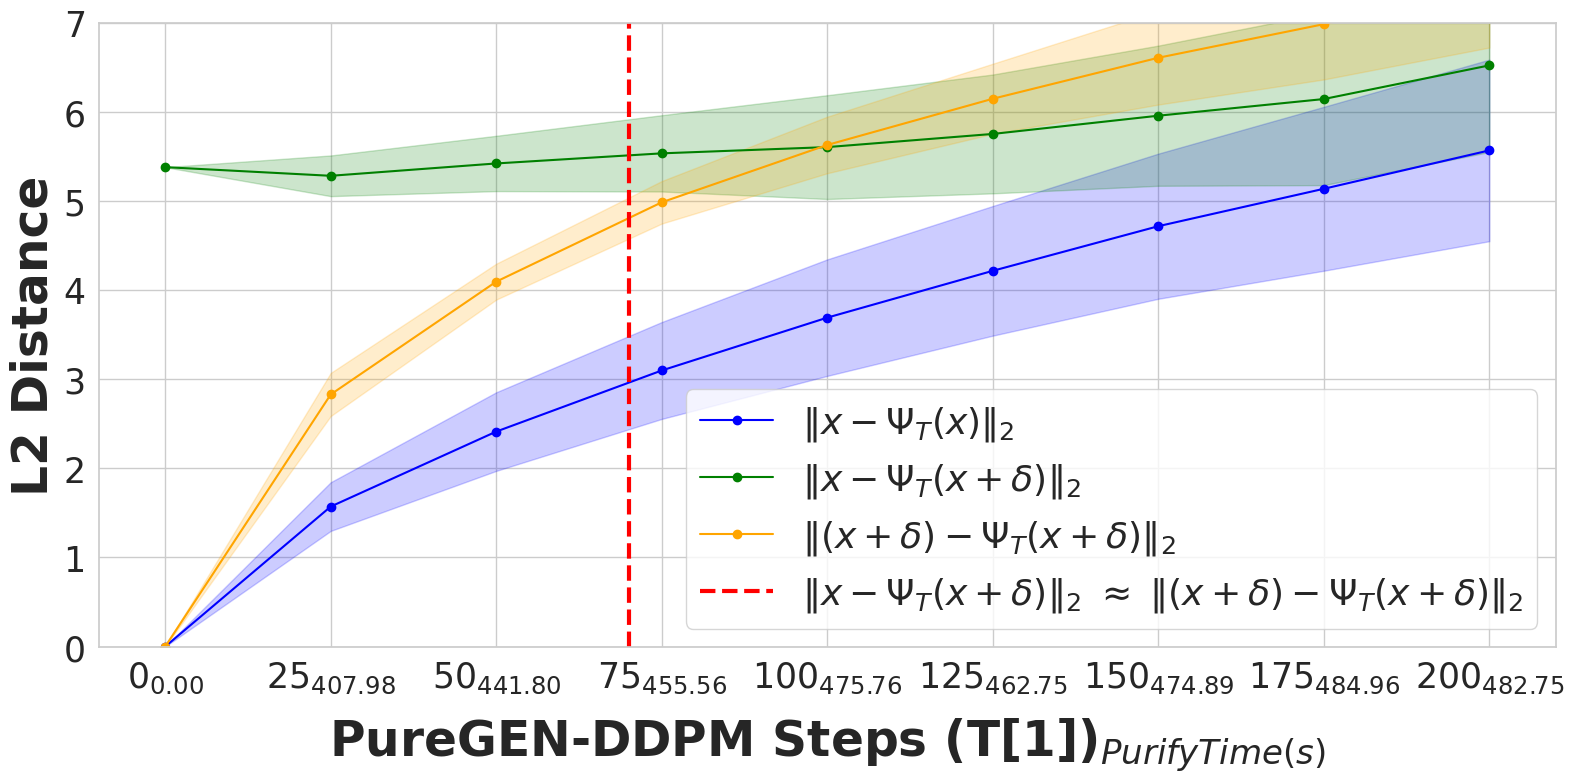

In [230]:
sns.set_style("whitegrid")

l2_dists_C_CP,l2_dists_C_PP,l2_dists_P_PP,l2_dists_CP_PP = np.array(l2_dists_C_CP), np.array(l2_dists_C_PP), np.array(l2_dists_P_PP), np.array(l2_dists_CP_PP)
pixel_dist_C_CP,pixel_dist_C_PP,pixel_dist_P_PP,pixel_dist_CP_PP = np.array(pixel_dist_C_CP), np.array(pixel_dist_C_PP), np.array(pixel_dist_P_PP), np.array(pixel_dist_CP_PP)


mean_l2_C_CP, mean_l2_C_PP, mean_l2_P_PP, mean_l2_CP_PP = l2_dists_C_CP.mean(axis=1), l2_dists_C_PP.mean(axis=1), l2_dists_P_PP.mean(axis=1), l2_dists_CP_PP.mean(axis=1)
std_l2_C_CP, std_l2_C_PP, std_l2_P_PP, std_l2_CP_PP = l2_dists_C_CP.std(axis=1), l2_dists_C_PP.std(axis=1), l2_dists_P_PP.std(axis=1), l2_dists_CP_PP.std(axis=1)

mean_pixel_dist_C_CP, mean_pixel_dist_C_PP, mean_pixel_dist_P_PP, mean_pixel_dist_CP_PP = pixel_dist_C_CP.mean(axis=1), pixel_dist_C_PP.mean(axis=1), pixel_dist_P_PP.mean(axis=1), pixel_dist_CP_PP.mean(axis=1)
std_pixel_dist_C_CP, std_pixel_dist_C_PP, std_pixel_dist_P_PP, std_pixel_dist_CP_PP = pixel_dist_C_CP.std(axis=1), pixel_dist_C_PP.std(axis=1), pixel_dist_P_PP.std(axis=1), pixel_dist_CP_PP.std(axis=1)

x_axis_labels = [f'${steps}_{{{purify_times[i]:.2f}}}$' for i,steps in enumerate(DDPM_STEPS)]

### L2 Dynamics
fig, ax1 = plt.subplots(1, 1, figsize=(16, 8))

ax1.plot(DDPM_STEPS, mean_l2_C_CP, '-o', label=r'$\| x - \Psi_T(x) \|_2$', color='blue')
ax1.fill_between(DDPM_STEPS, mean_l2_C_CP - std_l2_C_CP, mean_l2_C_CP + std_l2_C_CP, color='blue', alpha=0.2)
ax1.plot(DDPM_STEPS, mean_l2_C_PP, '-o', label=r'$\| x - \Psi_T(x + \delta) \|_2$', color='green')
ax1.fill_between(DDPM_STEPS, mean_l2_C_PP - std_l2_C_PP, mean_l2_C_PP + std_l2_C_PP, color='green', alpha=0.2)
ax1.plot(DDPM_STEPS, mean_l2_P_PP, '-o', label=r'$\| (x + \delta) - \Psi_T(x + \delta) \|_2$', color='orange')
ax1.fill_between(DDPM_STEPS, mean_l2_P_PP - std_l2_P_PP, mean_l2_P_PP + std_l2_P_PP, color='orange', alpha=0.2)

# Replace x-axis labels
ax1.set_xticks(DDPM_STEPS)
ax1.set_xticklabels(x_axis_labels)

ax1.set_ylabel('L2 Distance', fontsize=35,fontweight='bold')
ax1.set_xlabel('PureGEN-DDPM Steps (T[1])$_{{Purify Time (s)}}$', fontsize=35,fontweight='bold',labelpad=15)
ax1.tick_params(axis='both', which='major', labelsize=25)


# Dotted vline at 150
ax1.axvline(x=70, color='red', linestyle='--', label=r'$\| x - \Psi_T(x + \delta) \|_2$ $\approx$ $\| (x + \delta) - \Psi_T(x + \delta) \|_2$', linewidth=3)

ax1.legend(fontsize=26,loc='lower right')

ax1.set_ylim(0, 7)

plt.tight_layout()
plt.savefig(f'ddpm_L2_dynamics_Narc{EPS}.pdf')


### EBM

In [231]:

forward_transform = transforms.Compose([transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
inverse_transform = transforms.Compose([transforms.Normalize((-1, -1, -1), (2, 2, 2))])

# C- Clean, P - Poisoned, CP - Clean Purified, PP - Poisoned Purified

MCMC_STEPS = [5,10,50,100,150,250,400,600,800,1000,1200,1500,2000]

PC_Images = []
PP_images = []

l2_dists_C_CP = []
l2_dists_C_PP = []
l2_dists_P_PP = []
l2_dists_CP_PP = []

purify_times = [0]

pixel_dist_C_CP = []
pixel_dist_C_PP = []
pixel_dist_P_PP = []
pixel_dist_CP_PP = []

for steps in tqdm(MCMC_STEPS):
    if steps == 0:
        PC_Images.append(clean_data)
        PP_images.append(poisoned_data)
        
    else:
        start_time = time.time()
        PC_Images.append(inverse_transform(ebm_purify(ebm_model,forward_transform(clean_data).to(device),steps,langevin_temp=7.5e-5)))
        PP_images.append(inverse_transform(ebm_purify(ebm_model,forward_transform(poisoned_data).to(device),steps,langevin_temp=7.5e-5)))
        purify_times.append(time.time() - start_time)

    # L2 Distances
    l2_dists_C_CP.append([np.linalg.norm(clean_data[i] - PC_Images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_P_PP.append([np.linalg.norm(poisoned_data[i] - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_C_PP.append([np.linalg.norm(clean_data[i] - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])
    l2_dists_CP_PP.append([np.linalg.norm(PC_Images[-1][i].detach().cpu().numpy() - PP_images[-1][i].detach().cpu().numpy()) for i in range(len(clean_data))])

    # Convert images back to 0-255 space
    images_pure_255 = (clean_data * 255).int()
    poisoned_data_255 = (poisoned_data * 255).int()
    purified_pure_255 = (PC_Images[-1].detach().cpu() * 255).int()
    purified_poisoned_255 = (PP_images[-1].detach().cpu() * 255).int()

    # Calculate pixel distance for pure images
    pixel_dist_C_CP.append(torch.abs(images_pure_255 - purified_pure_255).numpy().flatten())
    pixel_dist_C_PP.append(torch.abs(images_pure_255 - purified_poisoned_255).numpy().flatten())
    pixel_dist_P_PP.append(torch.abs(poisoned_data_255 - purified_poisoned_255).numpy().flatten())
    pixel_dist_CP_PP.append(torch.abs(purified_pure_255 - purified_poisoned_255).numpy().flatten())

# PC and PP images save
torch.save(PC_Images,f'PC_images_EBM_Narc_{EPS}.pth')
torch.save(PP_images,'PP_images_EBM_Narc_{EPS}.pth')

100%|██████████| 13/13 [01:33<00:00,  7.19s/it]


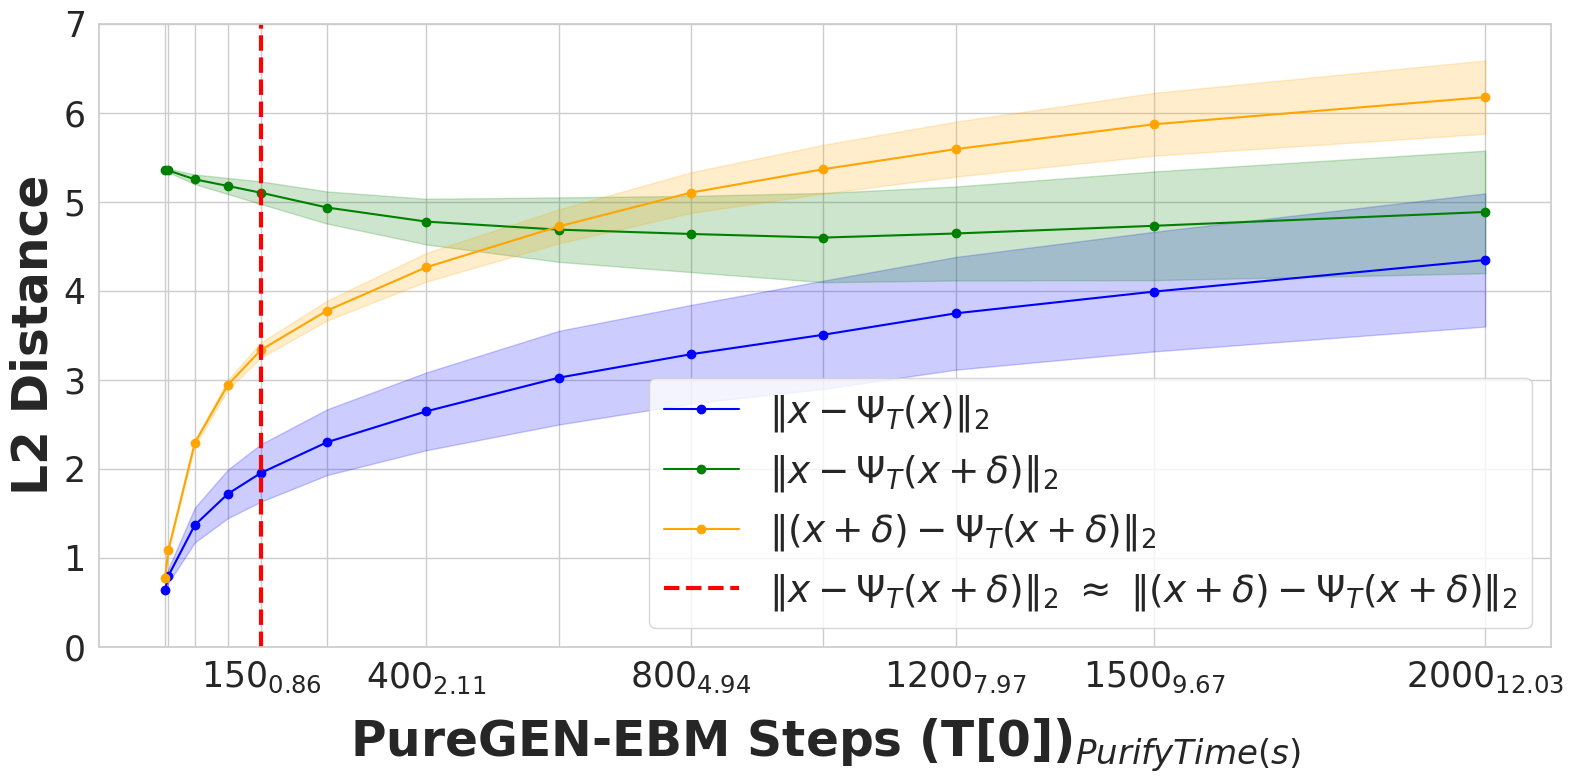

In [232]:
sns.set_style("whitegrid")
l2_dists_C_CP,l2_dists_C_PP,l2_dists_P_PP,l2_dists_CP_PP = np.array(l2_dists_C_CP), np.array(l2_dists_C_PP), np.array(l2_dists_P_PP), np.array(l2_dists_CP_PP)
pixel_dist_C_CP,pixel_dist_C_PP,pixel_dist_P_PP,pixel_dist_CP_PP = np.array(pixel_dist_C_CP), np.array(pixel_dist_C_PP), np.array(pixel_dist_P_PP), np.array(pixel_dist_CP_PP)


mean_l2_C_CP, mean_l2_C_PP, mean_l2_P_PP, mean_l2_CP_PP = l2_dists_C_CP.mean(axis=1), l2_dists_C_PP.mean(axis=1), l2_dists_P_PP.mean(axis=1), l2_dists_CP_PP.mean(axis=1)
std_l2_C_CP, std_l2_C_PP, std_l2_P_PP, std_l2_CP_PP = l2_dists_C_CP.std(axis=1), l2_dists_C_PP.std(axis=1), l2_dists_P_PP.std(axis=1), l2_dists_CP_PP.std(axis=1)

mean_pixel_dist_C_CP, mean_pixel_dist_C_PP, mean_pixel_dist_P_PP, mean_pixel_dist_CP_PP = pixel_dist_C_CP.mean(axis=1), pixel_dist_C_PP.mean(axis=1), pixel_dist_P_PP.mean(axis=1), pixel_dist_CP_PP.mean(axis=1)
std_pixel_dist_C_CP, std_pixel_dist_C_PP, std_pixel_dist_P_PP, std_pixel_dist_CP_PP = pixel_dist_C_CP.std(axis=1), pixel_dist_C_PP.std(axis=1), pixel_dist_P_PP.std(axis=1), pixel_dist_CP_PP.std(axis=1)


x_axis_labels = [f'${steps}_{{{purify_times[i]:.2f}}}$' for i,steps in enumerate(MCMC_STEPS)]
x_axis_labels[0] = ''
x_axis_labels[1] = ''
x_axis_labels[2] = ''
x_axis_labels[3] = ''
x_axis_labels[5] = ''
x_axis_labels[7] = ''
x_axis_labels[9] = ''
### L2 Dynamics
fig, ax1 = plt.subplots(1, 1, figsize=(16, 8))

ax1.plot(MCMC_STEPS, mean_l2_C_CP, '-o', label=r'$\| x - \Psi_T(x) \|_2$', color='blue')
ax1.fill_between(MCMC_STEPS, mean_l2_C_CP - std_l2_C_CP, mean_l2_C_CP + std_l2_C_CP, color='blue', alpha=0.2)
ax1.plot(MCMC_STEPS, mean_l2_C_PP, '-o', label=r'$\| x - \Psi_T(x + \delta) \|_2$', color='green')
ax1.fill_between(MCMC_STEPS, mean_l2_C_PP - std_l2_C_PP, mean_l2_C_PP + std_l2_C_PP, color='green', alpha=0.2)
ax1.plot(MCMC_STEPS, mean_l2_P_PP, '-o', label=r'$\| (x + \delta) - \Psi_T(x + \delta) \|_2$', color='orange')
ax1.fill_between(MCMC_STEPS, mean_l2_P_PP - std_l2_P_PP, mean_l2_P_PP + std_l2_P_PP, color='orange', alpha=0.2)

# Replace x-axis labels
ax1.set_xticks(MCMC_STEPS)
ax1.set_xticklabels(x_axis_labels)

ax1.set_ylabel('L2 Distance', fontsize=35,fontweight='bold')
ax1.set_xlabel('PureGEN-EBM Steps (T[0])$_{{Purify Time (s)}}$', fontsize=35,fontweight='bold',labelpad=15)
ax1.tick_params(axis='both', which='major', labelsize=25)

# Dotted vline at 150
ax1.axvline(x=150, color='red', linestyle='--', label=r'$\| x - \Psi_T(x + \delta) \|_2$ $\approx$ $\| (x + \delta) - \Psi_T(x + \delta) \|_2$', linewidth=3)

ax1.legend(fontsize=27,loc='lower right')

ax1.set_ylim(0, 7)

plt.tight_layout()
plt.savefig(f'ebm_L2_dynamics_Narc{EPS}.pdf')